In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================
# 1. 讀取與清理資料
# =========================
df = pd.read_csv('NBA_Normalized_Final_3.csv')

bool_cols = ['Is_Undrafted', 'Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})

# =========================
# 2. 篩選資料 (四年級 WS 預測)
# =========================
df_g = df[(df['season'] > 2) & (df['year_start'] > 1999) ].copy()

feature_cols = [
    '2P%','2PA','3P','3P%','3PA','3PAr','AST','AST%','BLK','BLK%','BPM','DBPM',
    'DRB','DRB%','DWS','FG','FG%','FGA','FT','FT%','FTA','FTr',
    'OBPM','ORB','ORB%','OWS','PER','PF','PTS','Pos_C','Pos_PF','Pos_PG',
    'Pos_SF','Pos_SG','STL','STL%','TOV','TOV%','TRB','TRB%','TS%','USG%',
    'VORP','WS','WS/48','eFG%'
]
target_col = 'Year4_WS'

data = df_g.dropna(subset=[target_col]).copy()
for c in feature_cols:
    data[c] = pd.to_numeric(data[c], errors='coerce')
data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
data = data.dropna(subset=[target_col]).copy()

X = data[feature_cols].copy()
y = data[target_col].copy()

# =========================
# 3. 切分訓練 / 測試 
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. 建立 Pipeline 與 GridSearchCV (自動尋找最佳 alpha & l1_ratio)
# =========================
alphas = np.logspace(-4, 1, 30)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
cv_splits = min(5, len(X_train))

# 建立管線
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(max_iter=200000, random_state=42, tol=1e-4))
])

# 使用 GridSearchCV
param_grid = {
    'enet__alpha': alphas,
    'enet__l1_ratio': l1_ratios
}

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv_splits, 
    scoring='r2', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# =========================
# 5. 計算各項指標
# =========================
# 取出最佳模型與參數
best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['enet__alpha']
best_l1_ratio = grid_search.best_params_['enet__l1_ratio']
best_cv_r2 = grid_search.best_score_

# 預測並計算 R2
train_r2 = r2_score(y_train, best_model.predict(X_train))
test_r2 = r2_score(y_test, best_model.predict(X_test))

# 計算 RMSE 與 MAE
y_pred_test = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

# 提取 Elastic Net 獨有的「特徵選擇」結果
enet_coefs = best_model.named_steps["enet"].coef_
n_total_features = len(feature_cols)
n_retained_features = np.sum(enet_coefs != 0)

# =========================
# 6. 正式輸出實戰報告
# =========================
print("\n" + "="*48)
print("       ELASTIC NET REGRESSION FINAL REPORT")
print("="*48)
print(f"1. Train R² (訓練集得分):   {train_r2:.4f}")
print(f"2. Best CV R² (交叉驗證):  {best_cv_r2:.4f}")
print(f"3. Test R² (實測測試集):   {test_r2:.4f}")
print("-" * 48)
print(f"Chosen Alpha (最佳懲罰):   {best_alpha:.4f}")
print(f"Chosen L1 Ratio (L1比例): {best_l1_ratio:.4f}")
print(f"Test RMSE:                {rmse_test:.4f}")
print(f"Test MAE:                 {mae_test:.4f}")
print(f"Feature Selection:        保留 {n_retained_features} / {n_total_features} 個特徵")
print("="*48)

# =========================
# 7. 顯示被 Elastic Net 保留的關鍵特徵
# =========================
coef_df = pd.DataFrame({"feature": feature_cols, "coef": enet_coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

# 只列出係數不為 0 的特徵
active_features = coef_df[coef_df["coef"] != 0].sort_values("abs_coef", ascending=False)

print(active_features[["feature", "coef"]].head(15).to_string(index=False))


       ELASTIC NET REGRESSION FINAL REPORT
1. Train R² (訓練集得分):   0.5067
2. Best CV R² (交叉驗證):  0.4745
3. Test R² (實測測試集):   0.4699
------------------------------------------------
Chosen Alpha (最佳懲罰):   0.1269
Chosen L1 Ratio (L1比例): 0.9000
Test RMSE:                1.9798
Test MAE:                 1.5940
Feature Selection:        保留 10 / 46 個特徵

📌 Elastic Net 認定最有價值的核心特徵 (排除係數為 0 的雜訊):
feature      coef
     WS  0.985244
   VORP  0.499559
    OWS  0.195988
    TOV  0.144583
    DRB  0.107879
 Pos_PF -0.046760
    TRB  0.035822
  Pos_C  0.026071
   TRB%  0.019105
    BLK  0.006433


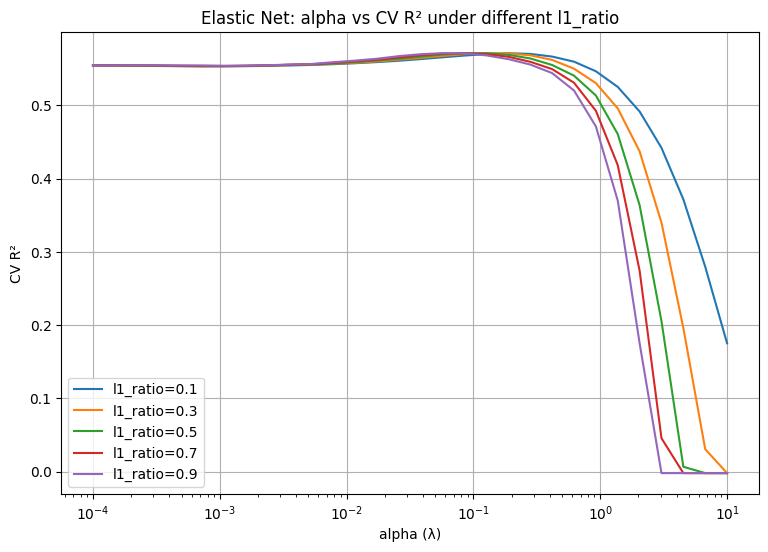

In [15]:
plt.figure(figsize=(9,6))
for r in l1_ratios:
    sub = res[res["l1_ratio"] == r].sort_values("alpha")
    plt.semilogx(sub["alpha"], sub["val_r2"], label=f"l1_ratio={r}")

plt.xlabel("alpha (λ)")
plt.ylabel("CV R²")
plt.title("Elastic Net: alpha vs CV R² under different l1_ratio")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
best_alpha = float(best["alpha"])
best_ratio = float(best["l1_ratio"])

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(
        alpha=best_alpha,
        l1_ratio=best_ratio,
        max_iter=200000,
        tol=1e-4,
        random_state=42
    ))
])

final_model.fit(X, y)

coef = pd.Series(final_model.named_steps["enet"].coef_, index=X.columns)
selected = coef[coef != 0].sort_values(key=np.abs, ascending=False)


print(selected)
print("非0特徵數量 =", (coef != 0).sum())



📌 Elastic Net 選到的特徵（按 |coef| 排序）
WS           1.104135
OWS          0.377426
VORP         0.283574
STL          0.249488
FT           0.142112
PER          0.086197
DraftRank   -0.078005
dtype: float64

✅ 非0特徵數量 = 7


In [7]:
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.impute import SimpleImputer  

# -------------------------
# 切 train/test
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# 建立 Elastic Net
# -------------------------
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(
        alpha=float(grid_search.best_params_['enet__alpha']),
        l1_ratio=float(grid_search.best_params_['enet__l1_ratio']),
        random_state=42,
        max_iter=10000
    ))
])

# -------------------------
# 訓練
# -------------------------
model.fit(X_train, y_train)

# -------------------------
# 預測
# -------------------------
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# -------------------------
# 基本誤差
# -------------------------
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_test = mean_absolute_error(y_test, y_test_pred)
medae_test = median_absolute_error(y_test, y_test_pred)

# -------------------------
# CV RMSE（只在 train 上）
# -------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

cv_rmse = -cv_scores
cv_mean = cv_rmse.mean()
cv_std  = cv_rmse.std(ddof=1)

# -------------------------
# Train–Test Gap
# -------------------------
gap = rmse_test - rmse_train

# -------------------------
# Spearman rank
# -------------------------
def spearman_corr(y_true, y_pred):
    rt = np.argsort(np.argsort(y_true))
    rp = np.argsort(np.argsort(y_pred))
    return np.corrcoef(rt, rp)[0, 1]

spearman = spearman_corr(y_test, y_test_pred)

# -------------------------
# 輸出
# -------------------------
print("\n===== Elastic Net Evaluation =====")
print(f"RMSE (test): {rmse_test:.6f}")
print(f"MAE  (test): {mae_test:.6f}")
print(f"MedianAE (test): {medae_test:.6f}")
print(f"CV RMSE (train, 5-fold): {cv_mean:.6f} ± {cv_std:.6f}")
print(f"Train–Test Gap (RMSE_test - RMSE_train): {gap:.6f}")
print(f"Spearman rank corr (test): {spearman:.6f}")


===== Elastic Net Evaluation =====
RMSE (test): 1.979751
MAE  (test): 1.593972
MedianAE (test): 1.305581
CV RMSE (train, 5-fold): 1.967060 ± 0.071038
Train–Test Gap (RMSE_test - RMSE_train): 0.049535
Spearman rank corr (test): 0.661309


In [127]:
#3
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# 1. 讀取資料
# =========================
df_main = pd.read_csv("NBA_Normalized_Final.csv")

# TRUE/FALSE 欄位處理
bool_cols = ['Is_Undrafted']
for col in bool_cols:
    if col in df_main.columns:
        df_main[col] = (
            df_main[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .map({
                "TRUE": 1, "FALSE": 0,
                "1": 1, "0": 0,
                "1.0": 1, "0.0": 0
            })
        )

# dummy 欄位處理
dummy_cols = ['Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']
for col in dummy_cols:
    if col in df_main.columns:
        df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

# 定義目標欄位
target_col = "Yearˇ_WS"



# 訓練集：剔除 Year3_WS 為空的球員 (不參與訓練)
df_train = df_main[
    (df_main["year_start"] != 2005) & 
    (df_main["season"] > 1) &
    (df_main[target_col].notna())  
].copy()

# 預測集
df_2000 = df_main[
    (df_main["year_start"] == 2005) & 
    (df_main["season"] > 1) & 
    (df_main['DraftRank'] < 31)
].copy()

# =========================
# 2. 特徵欄位轉換
# =========================
feature_cols = [
    '2P%', '2PA', '3P', '3P%', '3PA', '3PAr', 'AST', 'AST%', 'BLK', 'BLK%',
    'BPM', 'DBPM', 'DRB', 'DRB%', 'DWS', 'DraftRank', 'FG', 'FG%', 'FGA',
    'FT', 'FT%', 'FTA', 'FTr', 'OBPM', 'ORB', 'ORB%', 'OWS', 'PER', 'PF',
    'PTS', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG', 'STL', 'STL%',
    'TOV', 'TOV%', 'TRB', 'TRB%', 'TS%', 'USG%', 'VORP', 'WS', 'WS/48',
    'eFG%', 'Is_Undrafted'
]

# 全部轉數值並確保訓練標籤為數值
for col in feature_cols:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')
    df_2000[col] = pd.to_numeric(df_2000[col], errors='coerce')

df_train[target_col] = pd.to_numeric(df_train[target_col], errors='coerce')

X_train = df_train[feature_cols]
y_train = df_train[target_col]
X_pred = df_2000[feature_cols] 

print(f"訓練樣本數：{len(X_train)}")
print(f"預測樣本數：{len(X_pred)}")

# =========================
# 3. 訓練模型
# =========================

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNet(alpha=0.1, l1_ratio=0.5)) 
])

final_model.fit(X_train, y_train)

# =========================
# 4. 預測：這一步會算出「所有人」的預期產出
# =========================
df_2000["Pred_WS"] = final_model.predict(X_pred).ravel()

# =========================
# 5. 經濟價值計算 (邏輯保持不變)
# =========================
try:
    eco_ref = df_main[df_main["year_start"] == 2005].iloc[0]
    SALARY_CAP_2000 = eco_ref['Salary_Cap_At_Start']
    BRI_FACTOR_2000 = eco_ref['BRI_Factor']
    TEAM_COUNT_2000 = 30 
    TOTAL_GAMES = 1230
    marginal_value_per_ws = (SALARY_CAP_2000 * TEAM_COUNT_2000 * BRI_FACTOR_2000) / TOTAL_GAMES
except:
    SALARY_CAP_2000 = 57.7
    marginal_value_per_ws = 2.5 

df_2000["Pred_Dollar_Value_M"] = df_2000["Pred_WS"] * marginal_value_per_ws
df_2000["Pred_Salary_Share_Percent"] = (df_2000["Pred_Dollar_Value_M"] / SALARY_CAP_2000) * 100

def get_cost_percent(row):
    rank = row["DraftRank"]
    if 1 <= rank <= 30:
        return 8.0 - (rank - 1) * (6.5 / 29)
    return 1.1

df_2000["Est_Cost_Percent"] = df_2000.apply(get_cost_percent, axis=1)
df_2000["Pred_ROI"] = df_2000["Pred_Salary_Share_Percent"] / df_2000["Est_Cost_Percent"]
df_2000["Net_Surplus_Percent"] = df_2000["Pred_Salary_Share_Percent"] - df_2000["Est_Cost_Percent"]

# =========================
# 6. 結果 
# =========================
result = df_2000[[
    "Player", "DraftRank", "Pred_WS", "Year4_WS", 
    "Pred_Salary_Share_Percent", "Est_Cost_Percent", "Pred_ROI","Net_Surplus_Percent"
]].sort_values("Pred_WS", ascending=False)


print(result)

訓練樣本數 (有第三年成績)：1109
預測樣本數 (2009梯次全體)：28
=== 2009年球員經濟價值預測（包含第三年未出賽球員） ===
                 Player  DraftRank   Pred_WS  Year4_WS  \
1659      Dwight Howard        1.0  8.416892      12.9   
1639     Andre Iguodala        9.0  8.379659       9.6   
1681          Luol Deng        7.0  6.953880       4.4   
1673     Josh Childress        6.0  6.146636       7.6   
1676       Kevin Martin       26.0  5.989625       8.4   
1644         Ben Gordon        3.0  5.915481       5.1   
1655       Devin Harris        5.0  5.162058       5.6   
1669      Jameer Nelson       20.0  4.671744       5.6   
1674         Josh Smith       17.0  4.639362       5.8   
1660       Emeka Okafor        2.0  4.628061       5.8   
1654       Delonte West       24.0  4.397501       1.3   
1770     Raymond Felton        5.0  4.141831       3.4   
1635       Al Jefferson       15.0  4.074902       7.7   
1687      Nick Collison       12.0  4.003642       4.5   
1739   Francisco Garcia       23.0  3.555736       4.2  

C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Pos_C' 'Pos_PF' 'Pos_PG' 'Pos_SF' 'Pos_SG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Pos_C' 'Pos_PF' 'Pos_PG' 'Pos_SF' 'Pos_SG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


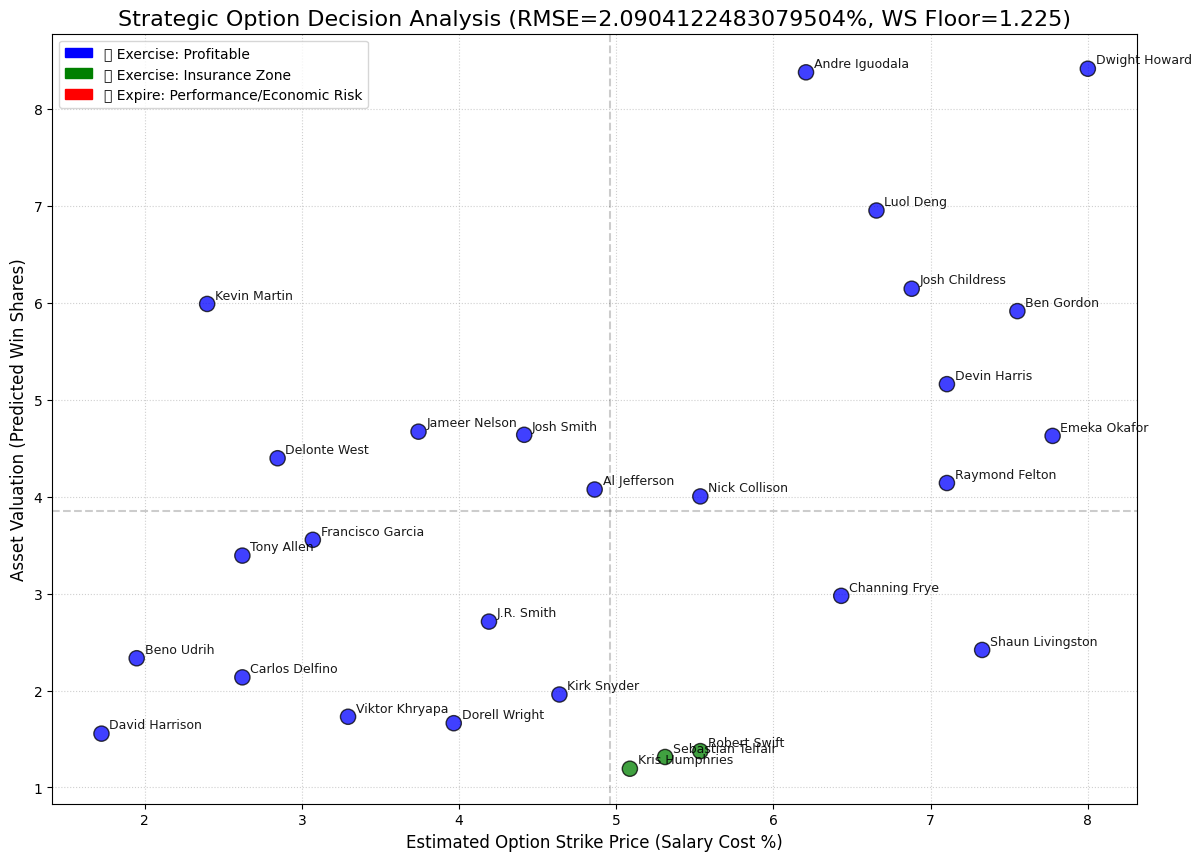


=== 模型判定為「建議放棄(紅色)」的球員清單 ===
Empty DataFrame
Columns: [Player, DraftRank, Pred_WS, Net_Surplus_Percent]
Index: []


In [128]:
#4
# ==========================================
# 1. 準備繪圖數據
# ==========================================
rmse_threshold = rmse_test

# ==========================================
# 2. 修正後的顏色邏輯 (優先判定「絕對止損」)
# ==========================================
conditions = [
                     
    (df_2000["Net_Surplus_Percent"] < -rmse_threshold),    
    (df_2000["Net_Surplus_Percent"] > 0),                   
    (df_2000["Net_Surplus_Percent"] <= 0) & (df_2000["Net_Surplus_Percent"] >= -rmse_threshold)
]
choices = [ "red", "blue", "green"]
colors = np.select(conditions, choices, default="gray")

# ==========================================
# 3. 繪圖
# ==========================================
plt.figure(figsize=(14, 10))

x = df_2000["Est_Cost_Percent"]
y = df_2000["Pred_WS"]

plt.scatter(x, y, c=colors, s=120, alpha=0.75, edgecolors="black", linewidth=1, zorder=3)




plt.axvline(x.mean(), color="black", linestyle="--", alpha=0.2)
plt.axhline(y.mean(), color="black", linestyle="--", alpha=0.2)


for i, row in df_2000.iterrows():
    plt.text(
        row["Est_Cost_Percent"] + 0.05, 
        row["Pred_WS"] + 0.05,
        row["Player"],
        fontsize=9,
        # 如果是被放棄的球員，字體稍微淡一點
        alpha=0.9
    )

plt.xlabel("Estimated Option Strike Price (Salary Cost %)", fontsize=12)
plt.ylabel("Asset Valuation (Predicted Win Shares)", fontsize=12)
plt.title(f"Strategic Option Decision Analysis (RMSE={rmse_threshold}%, WS Floor={ws_floor})", fontsize=16)

# ==========================================
# 4. 圖例
# ==========================================
blue_patch = mpatches.Patch(color='blue', label='🔵 Exercise: Profitable')
green_patch = mpatches.Patch(color='green', label='🟢 Exercise: Insurance Zone')
red_patch = mpatches.Patch(color='red', label='🔴 Expire: Performance/Economic Risk')
plt.legend(handles=[blue_patch, green_patch, red_patch], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# 5. 輸出決策
# ==========================================
print("建議放棄球員清單")
red_zone = df_2000[(df_2000["Net_Surplus_Percent"] < -rmse_threshold)]
print(red_zone[["Player", "DraftRank", "Pred_WS", "Net_Surplus_Percent"]].sort_values("Pred_WS"))

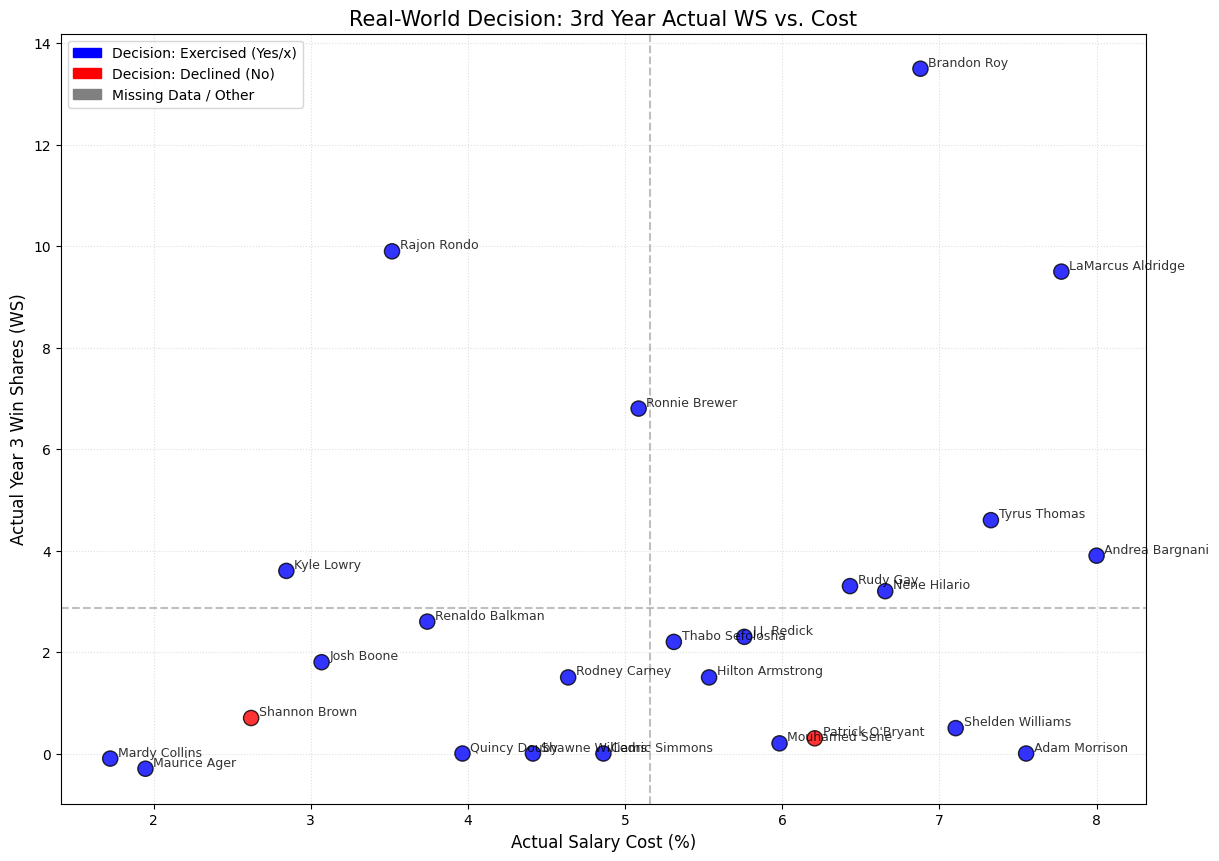


【 補充報告：未出現在圖表上或被放棄之球員清單 】
說明：包含實際決策為 'No' 或第三年無出賽紀錄(WS為空)之球員
          Player  DraftRank Actual_Decision  Actual_WS
   Shannon Brown       25.0              no        0.7
Patrick O'Bryant        9.0              no        0.3


In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ==========================================
# 1. 準備數據與顏色
# ==========================================
df_2000['year_3_clean'] = df_2000['year_3'].astype(str).str.strip().str.lower()


color_map = {'yes': 'blue', 'no': 'red', 'x': 'blue', 're-sign':'blue'} # 根據你之前的資料，x 通常也是執行
df_2000['plot_color'] = df_2000['year_3_clean'].map(color_map).fillna('gray')


df_plot = df_2000.dropna(subset=['Year3_WS']).copy()

# ==========================================
# 2. 繪製實際決策圖表
# ==========================================
plt.figure(figsize=(14, 10))

x = df_plot["Est_Cost_Percent"]
y = df_plot["Year3_WS"]

plt.scatter(
    x, y, 
    c=df_plot['plot_color'], 
    s=120, alpha=0.8, edgecolors="black", linewidth=1, zorder=3
)

# 畫出平均基準線
plt.axvline(x.mean(), color="gray", linestyle="--", alpha=0.5)
plt.axhline(y.mean(), color="gray", linestyle="--", alpha=0.5)

# 標記球員姓名
for i, row in df_plot.iterrows():
    plt.text(row["Est_Cost_Percent"] + 0.05, row["Year3_WS"] + 0.05, 
             row["Player"], fontsize=9, alpha=0.8)

plt.xlabel("Actual Salary Cost (%)", fontsize=12)
plt.ylabel("Actual Year 3 Win Shares (WS)", fontsize=12)
plt.title("Real-World Decision: 3rd Year Actual WS vs. Cost", fontsize=15)

# 圖例
blue_patch = mpatches.Patch(color='blue', label='Decision: Exercised (Yes/x)')
red_patch = mpatches.Patch(color='red', label='Decision: Declined (No)')
gray_patch = mpatches.Patch(color='gray', label='Missing Data / Other')
plt.legend(handles=[blue_patch, red_patch, gray_patch], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

# ==========================================
# 3. 列出所有「未續約」或「沒數據」的球員清單
# ==========================================
print("\n" + "="*50)
print("未出現在圖表上或被放棄之球員清單")
print("="*50)

# 篩選條件：(決策為 No) 或 (Year3_WS 為空)
missing_or_no = df_2000[
    (df_2000['year_3_clean'] == 'no') | 
    (df_2000['Year3_WS'].isna())
].copy()

if not missing_or_no.empty:
    # 整理輸出格式
    list_report = missing_or_no[[
        "Player", "DraftRank", "year_3", "Year3_WS"
    ]].rename(columns={"year_3": "Actual_Decision", "Year3_WS": "Actual_WS"})
    
    print(list_report.to_string(index=False))
else:
    print("查無此類球員")
print("="*50)